In [ ]:
# ============================================================
# PS8.3 — Penalty-Matrix Calibration
# ============================================================
# Builds a daily (Delta, Gamma, Vega) portfolio series from the trade-tape
# CSV + SABR-fitted vol, then computes the empirical covariance matrix
# used as the quadratic inventory penalty M in the El Aoud-Abergel solver.
# ============================================================

import re
import numpy as np
import pandas as pd
import torch

torch.manual_seed(42)

CSV_PATH = 'BTC-USD-optionchain-trades-2026-05.csv'
WEEK_START = '2026-05-22'   # <-- pick a 7-day window with good liquidity (use find_snapshot.py logic)
WEEK_END = '2026-05-28'
MIN_TRADES_PER_DAY = 5
RATE = 0.0

# ------------------------------------------------------------
# 1. BS Greeks — reuses the team's PS6.1 module (bs_autograd_greeks.py)
#    as the single source of truth, so Greeks are computed identically
#    everywhere in the project. That module only prices calls; puts are
#    derived via put-call parity, which shares Black-Scholes' gamma and
#    vega with the call and shifts delta by exactly -1 (verified against
#    finite differences on the direct put price: matches to ~5 sig figs).
# ------------------------------------------------------------
import sys
sys.path.insert(0, './tools')   # folder containing bs_autograd_greeks.py
from bs_autograd_greeks import autograd_call_greeks

def bs_greeks(S_val, K_val, tau_val, sigma_val, r_val, cp):
    """Returns (delta, gamma, vega) as floats, for either a call or a put."""
    g = autograd_call_greeks(S0=S_val, K=K_val, T0=tau_val, r0=r_val, sigma0=sigma_val)
    if cp == 'C':
        return g['delta'], g['gamma'], g['vega']
    else:  # put via parity: delta_put = delta_call - 1; gamma, vega unchanged
        return g['delta'] - 1.0, g['gamma'], g['vega']


# ------------------------------------------------------------
# 2. Load trades, parse contracts
# ------------------------------------------------------------
def parse_instrument(name):
    m = re.match(r'BTC-USD-(\d{6})-(\d+)-([CP])', name)
    if not m:
        return None
    yymmdd, strike, cp = m.groups()
    expiry = pd.Timestamp(f"20{yymmdd[0:2]}-{yymmdd[2:4]}-{yymmdd[4:6]}")
    return float(strike), expiry, cp

df = pd.read_csv(CSV_PATH)
df['dt'] = pd.to_datetime(df['created_time'], unit='ms')
df['date'] = df['dt'].dt.date
parsed = df['instrument_name'].apply(parse_instrument)
df['strike'] = parsed.apply(lambda x: x[0] if x else None)
df['expiry'] = parsed.apply(lambda x: x[1] if x else None)
df['cp'] = parsed.apply(lambda x: x[2] if x else None)
df = df.dropna(subset=['strike', 'expiry'])

week_df = df[(df['date'] >= pd.Timestamp(WEEK_START).date()) &
             (df['date'] <= pd.Timestamp(WEEK_END).date())].copy()
print(f"Trades in window {WEEK_START} to {WEEK_END}: {len(week_df)}")

# ------------------------------------------------------------
# 3. Forward via put-call parity, per day (reused from PS6.4)
# ------------------------------------------------------------
def estimate_forward(day_trades):
    last_price = (day_trades.sort_values('created_time')
                  .groupby(['strike', 'cp'])['price'].last()
                  .unstack('cp'))
    if 'C' not in last_price.columns or 'P' not in last_price.columns:
        return None
    both = last_price.dropna(subset=['C', 'P'])
    if len(both) < 3:
        return None
    rough_spot = day_trades.groupby('strike').size().idxmax()
    estimates = [K + (row['C'] * rough_spot - row['P'] * rough_spot) for K, row in both.iterrows()]
    return float(np.median(estimates))


# ------------------------------------------------------------
# 4. Simple per-day vol proxy (ATM straddle -> flat vol for the book)
#    Simplification: rather than re-running full SABR per day (expensive
#    for a 7-day loop), use a single representative vol per day from the
#    contract nearest the forward. This is a deliberate simplification --
#    document it in the write-up as a place a full per-day SVI/SABR
#    surface (Problem 6/PS5) would improve accuracy.
# ------------------------------------------------------------
from scipy.stats import norm
from scipy.optimize import brentq

def bs_price_np(S, K, tau, sigma, r, cp):
    if sigma <= 0 or tau <= 0:
        return max(S - K, 0.0) if cp == 'C' else max(K - S, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    if cp == 'C':
        return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    else:
        return K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)

def implied_vol_np(price_usd, S, K, tau, r, cp):
    intrinsic = max(S - K, 0.0) if cp == 'C' else max(K - S, 0.0)
    if price_usd <= intrinsic + 1e-8:
        return np.nan
    try:
        return brentq(lambda s: bs_price_np(S, K, tau, s, r, cp) - price_usd, 1e-4, 5.0)
    except ValueError:
        return np.nan


# ------------------------------------------------------------
# 5. Build the daily portfolio Greek series
# ------------------------------------------------------------
records = []
for day, day_trades in week_df.groupby('date'):
    forward = estimate_forward(day_trades)
    if forward is None:
        print(f"{day}: skipped (insufficient C/P pairs for parity)")
        continue

    day_delta, day_gamma, day_vega = 0.0, 0.0, 0.0
    n_contracts = 0
    for (strike, expiry, cp), g in day_trades.groupby(['strike', 'expiry', 'cp']):
        if len(g) < MIN_TRADES_PER_DAY:
            continue
        tau = (expiry - pd.Timestamp(day)).days / 365.0
        if tau <= 0:
            continue
        last_price_btc = g.sort_values('created_time')['price'].iloc[-1]
        price_usd = last_price_btc * forward
        iv = implied_vol_np(price_usd, forward, strike, tau, RATE, cp)
        if np.isnan(iv) or iv < 0.05 or iv > 3.0:
            continue
        try:
            d, gam, v = bs_greeks(forward, strike, tau, iv, RATE, cp)
        except Exception:
            continue
        # weight by traded size that day, as a proxy for book exposure
        size = g['size'].sum()
        day_delta += d * size
        day_gamma += gam * size
        day_vega += v * size
        n_contracts += 1

    if n_contracts == 0:
        print(f"{day}: skipped (no contracts passed filters)")
        continue
    records.append({'date': day, 'forward': forward, 'n_contracts': n_contracts,
                     'delta': day_delta, 'gamma': day_gamma, 'vega': day_vega})
    print(f"{day}: F={forward:.0f}, {n_contracts} contracts, "
          f"Delta={day_delta:.2f} Gamma={day_gamma:.4f} Vega={day_vega:.2f}")

book = pd.DataFrame(records)
print(f"\nBuilt {len(book)}-day Greek series")
print(book[['date', 'delta', 'gamma', 'vega']].to_string(index=False))

if len(book) < 4:
    raise ValueError(
        "Fewer than 4 usable days — widen WEEK_START/WEEK_END or lower "
        "MIN_TRADES_PER_DAY. Covariance from <4 points is not meaningful."
    )

# ------------------------------------------------------------
# 6. Empirical covariance -> penalty matrix M
# ------------------------------------------------------------
greek_matrix = book[['delta', 'gamma', 'vega']].values
M = np.cov(greek_matrix, rowvar=False)   # 3x3, ddof=1 by default

print("\n=== Penalty matrix M (empirical covariance of daily Delta/Gamma/Vega) ===")
print(pd.DataFrame(M, index=['Delta', 'Gamma', 'Vega'], columns=['Delta', 'Gamma', 'Vega']))

# ------------------------------------------------------------
# 7. Per-entry justification (data-driven, printed automatically)
# ------------------------------------------------------------
labels = ['Delta', 'Gamma', 'Vega']
print("\n=== Entry-by-entry justification ===")
for i in range(3):
    for j in range(i, 3):
        val = M[i, j]
        if i == j:
            print(f"M[{labels[i]},{labels[i]}] = {val:.6g}  "
                  f"(variance of daily {labels[i]} exposure across the {len(book)}-day window)")
        else:
            corr = M[i, j] / np.sqrt(M[i, i] * M[j, j]) if M[i, i] > 0 and M[j, j] > 0 else float('nan')
            direction = "co-move (same direction)" if val > 0 else "offset each other" if val < 0 else "are uncorrelated"
            print(f"M[{labels[i]},{labels[j]}] = {val:.6g}  (correlation={corr:.3f}) "
                  f"-> {labels[i]} and {labels[j]} tend to {direction} across days in this window")

book.to_csv('daily_greek_book.csv', index=False)
np.savetxt('penalty_matrix.csv', M, delimiter=',', header='Delta,Gamma,Vega', comments='')
print("\nSaved daily_greek_book.csv and penalty_matrix.csv")

Trades in window 2026-05-22 to 2026-05-28: 63638
2026-05-22: F=76302, 226 contracts, Delta=-47634.84 Gamma=64.5573 Vega=1071685689.09
2026-05-23: F=76451, 221 contracts, Delta=52258.25 Gamma=51.1666 Vega=781027449.33
2026-05-24: F=76738, 182 contracts, Delta=11387.08 Gamma=49.2037 Vega=622925404.53
2026-05-25: F=77327, 206 contracts, Delta=-63528.15 Gamma=76.9561 Vega=1430306722.76
2026-05-26: F=76080, 235 contracts, Delta=-145689.01 Gamma=108.7682 Vega=1674827675.16
2026-05-27: F=74642, 221 contracts, Delta=-42342.18 Gamma=66.0019 Vega=1368094463.55
2026-05-28: F=73555, 281 contracts, Delta=18454.49 Gamma=96.1715 Vega=1800526032.65

Built 7-day Greek series
      date          delta      gamma         vega
2026-05-22  -47634.839395  64.557254 1.071686e+09
2026-05-23   52258.247456  51.166633 7.810274e+08
2026-05-24   11387.078439  49.203698 6.229254e+08
2026-05-25  -63528.148598  76.956087 1.430307e+09
2026-05-26 -145689.014578 108.768202 1.674828e+09
2026-05-27  -42342.181874  66.001

In [ ]:
# ============================================================
# PS8.3 — Penalty-Matrix Calibration
# ============================================================
# Builds a daily (Delta, Gamma, Vega) portfolio series from the trade-tape
# CSV + SABR-fitted vol, then computes the empirical covariance matrix
# used as the quadratic inventory penalty M in the El Aoud-Abergel solver.
# ============================================================

import re
import numpy as np
import pandas as pd
import torch

torch.manual_seed(42)

CSV_PATH = 'BTC-USD-optionchain-trades-2026-05.csv'
WEEK_START = '2026-05-22'   # <-- pick a 7-day window with good liquidity (use find_snapshot.py logic)
WEEK_END = '2026-05-28'
MIN_TRADES_PER_DAY = 5
RATE = 0.0

# ------------------------------------------------------------
# 1. BS Greeks — reuses the team's PS6.1 module (bs_autograd_greeks.py)
#    as the single source of truth, so Greeks are computed identically
#    everywhere in the project. That module only prices calls; puts are
#    derived via put-call parity, which shares Black-Scholes' gamma and
#    vega with the call and shifts delta by exactly -1 (verified against
#    finite differences on the direct put price: matches to ~5 sig figs).
# ------------------------------------------------------------
import sys
sys.path.insert(0, './tools')   # folder containing bs_autograd_greeks.py
from bs_autograd_greeks import autograd_call_greeks

def bs_greeks(S_val, K_val, tau_val, sigma_val, r_val, cp):
    """Returns (delta, gamma, vega) as floats, for either a call or a put."""
    g = autograd_call_greeks(S0=S_val, K=K_val, T0=tau_val, r0=r_val, sigma0=sigma_val)
    if cp == 'C':
        return g['delta'], g['gamma'], g['vega']
    else:  # put via parity: delta_put = delta_call - 1; gamma, vega unchanged
        return g['delta'] - 1.0, g['gamma'], g['vega']


# ------------------------------------------------------------
# 2. Load trades, parse contracts
# ------------------------------------------------------------
def parse_instrument(name):
    m = re.match(r'BTC-USD-(\d{6})-(\d+)-([CP])', name)
    if not m:
        return None
    yymmdd, strike, cp = m.groups()
    expiry = pd.Timestamp(f"20{yymmdd[0:2]}-{yymmdd[2:4]}-{yymmdd[4:6]}")
    return float(strike), expiry, cp

df = pd.read_csv(CSV_PATH)
df['dt'] = pd.to_datetime(df['created_time'], unit='ms')
df['date'] = df['dt'].dt.date
parsed = df['instrument_name'].apply(parse_instrument)
df['strike'] = parsed.apply(lambda x: x[0] if x else None)
df['expiry'] = parsed.apply(lambda x: x[1] if x else None)
df['cp'] = parsed.apply(lambda x: x[2] if x else None)
df = df.dropna(subset=['strike', 'expiry'])

week_df = df[(df['date'] >= pd.Timestamp(WEEK_START).date()) &
             (df['date'] <= pd.Timestamp(WEEK_END).date())].copy()
print(f"Trades in window {WEEK_START} to {WEEK_END}: {len(week_df)}")

# ------------------------------------------------------------
# 3. Forward via put-call parity, per day (reused from PS6.4)
# ------------------------------------------------------------
def estimate_forward(day_trades):
    last_price = (day_trades.sort_values('created_time')
                  .groupby(['strike', 'cp'])['price'].last()
                  .unstack('cp'))
    if 'C' not in last_price.columns or 'P' not in last_price.columns:
        return None
    both = last_price.dropna(subset=['C', 'P'])
    if len(both) < 3:
        return None
    rough_spot = day_trades.groupby('strike').size().idxmax()
    estimates = [K + (row['C'] * rough_spot - row['P'] * rough_spot) for K, row in both.iterrows()]
    return float(np.median(estimates))


# ------------------------------------------------------------
# 4. Simple per-day vol proxy (ATM straddle -> flat vol for the book)
#    Simplification: rather than re-running full SABR per day (expensive
#    for a 7-day loop), use a single representative vol per day from the
#    contract nearest the forward. This is a deliberate simplification --
#    document it in the write-up as a place a full per-day SVI/SABR
#    surface (Problem 6/PS5) would improve accuracy.
# ------------------------------------------------------------
from scipy.stats import norm
from scipy.optimize import brentq

def bs_price_np(S, K, tau, sigma, r, cp):
    if sigma <= 0 or tau <= 0:
        return max(S - K, 0.0) if cp == 'C' else max(K - S, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    if cp == 'C':
        return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    else:
        return K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)

def implied_vol_np(price_usd, S, K, tau, r, cp):
    intrinsic = max(S - K, 0.0) if cp == 'C' else max(K - S, 0.0)
    if price_usd <= intrinsic + 1e-8:
        return np.nan
    try:
        return brentq(lambda s: bs_price_np(S, K, tau, s, r, cp) - price_usd, 1e-4, 5.0)
    except ValueError:
        return np.nan


# ------------------------------------------------------------
# 5. Build the daily portfolio Greek series
# ------------------------------------------------------------
records = []
for day, day_trades in week_df.groupby('date'):
    forward = estimate_forward(day_trades)
    if forward is None:
        print(f"{day}: skipped (insufficient C/P pairs for parity)")
        continue

    day_delta, day_gamma, day_vega = 0.0, 0.0, 0.0
    n_contracts = 0
    for (strike, expiry, cp), g in day_trades.groupby(['strike', 'expiry', 'cp']):
        if len(g) < MIN_TRADES_PER_DAY:
            continue
        tau = (expiry - pd.Timestamp(day)).days / 365.0
        if tau <= 0:
            continue
        last_price_btc = g.sort_values('created_time')['price'].iloc[-1]
        price_usd = last_price_btc * forward
        iv = implied_vol_np(price_usd, forward, strike, tau, RATE, cp)
        if np.isnan(iv) or iv < 0.05 or iv > 3.0:
            continue
        try:
            d, gam, v = bs_greeks(forward, strike, tau, iv, RATE, cp)
        except Exception:
            continue
        # weight by SIGNED traded size (buy=+, sell=-), as a proxy for net
        # position accumulated that day. Using unsigned total volume here
        # would treat a contract with equal buying and selling as if it
        # were a large one-directional position -- it isn't, it's flat.
        signed_size = g.loc[g['side'] == 'buy', 'size'].sum() - g.loc[g['side'] == 'sell', 'size'].sum()
        day_delta += d * signed_size
        day_gamma += gam * signed_size
        day_vega += v * signed_size
        n_contracts += 1

    if n_contracts == 0:
        print(f"{day}: skipped (no contracts passed filters)")
        continue
    records.append({'date': day, 'forward': forward, 'n_contracts': n_contracts,
                     'delta': day_delta, 'gamma': day_gamma, 'vega': day_vega})
    print(f"{day}: F={forward:.0f}, {n_contracts} contracts, "
          f"Delta={day_delta:.2f} Gamma={day_gamma:.4f} Vega={day_vega:.2f}")

book = pd.DataFrame(records)
print(f"\nBuilt {len(book)}-day Greek series")
print(book[['date', 'delta', 'gamma', 'vega']].to_string(index=False))

if len(book) < 4:
    raise ValueError(
        "Fewer than 4 usable days — widen WEEK_START/WEEK_END or lower "
        "MIN_TRADES_PER_DAY. Covariance from <4 points is not meaningful."
    )

# ------------------------------------------------------------
# 6. Empirical covariance -> penalty matrix M
# ------------------------------------------------------------
greek_matrix = book[['delta', 'gamma', 'vega']].values
M = np.cov(greek_matrix, rowvar=False)   # 3x3, ddof=1 by default

print("\n=== Penalty matrix M (empirical covariance of daily Delta/Gamma/Vega) ===")
print(pd.DataFrame(M, index=['Delta', 'Gamma', 'Vega'], columns=['Delta', 'Gamma', 'Vega']))

# ------------------------------------------------------------
# 7. Per-entry justification (data-driven, printed automatically)
# ------------------------------------------------------------
labels = ['Delta', 'Gamma', 'Vega']
print("\n=== Entry-by-entry justification ===")
for i in range(3):
    for j in range(i, 3):
        val = M[i, j]
        if i == j:
            print(f"M[{labels[i]},{labels[i]}] = {val:.6g}  "
                  f"(variance of daily {labels[i]} exposure across the {len(book)}-day window)")
        else:
            corr = M[i, j] / np.sqrt(M[i, i] * M[j, j]) if M[i, i] > 0 and M[j, j] > 0 else float('nan')
            direction = "co-move (same direction)" if val > 0 else "offset each other" if val < 0 else "are uncorrelated"
            print(f"M[{labels[i]},{labels[j]}] = {val:.6g}  (correlation={corr:.3f}) "
                  f"-> {labels[i]} and {labels[j]} tend to {direction} across days in this window")

book.to_csv('daily_greek_book.csv', index=False)
np.savetxt('penalty_matrix.csv', M, delimiter=',', header='Delta,Gamma,Vega', comments='')
print("\nSaved daily_greek_book.csv and penalty_matrix.csv")

Trades in window 2026-05-22 to 2026-05-28: 63638
2026-05-22: F=76302, 226 contracts, Delta=6665.08 Gamma=-7.3670 Vega=-226105426.94
2026-05-23: F=76451, 221 contracts, Delta=4281.12 Gamma=-1.2352 Vega=-58552340.15
2026-05-24: F=76738, 182 contracts, Delta=10755.78 Gamma=-6.0647 Vega=-146226195.88
2026-05-25: F=77327, 206 contracts, Delta=-30727.42 Gamma=-0.6901 Vega=4339171.44
2026-05-26: F=76080, 235 contracts, Delta=-72817.43 Gamma=11.7112 Vega=190552185.86
2026-05-27: F=74642, 221 contracts, Delta=-8393.14 Gamma=-6.8719 Vega=69117056.37
2026-05-28: F=73555, 281 contracts, Delta=-25184.43 Gamma=-20.4604 Vega=-107343557.00

Built 7-day Greek series
      date         delta      gamma          vega
2026-05-22   6665.075101  -7.367024 -2.261054e+08
2026-05-23   4281.115995  -1.235219 -5.855234e+07
2026-05-24  10755.777244  -6.064717 -1.462262e+08
2026-05-25 -30727.424154  -0.690124  4.339171e+06
2026-05-26 -72817.431110  11.711206  1.905522e+08
2026-05-27  -8393.139834  -6.871940  6.911

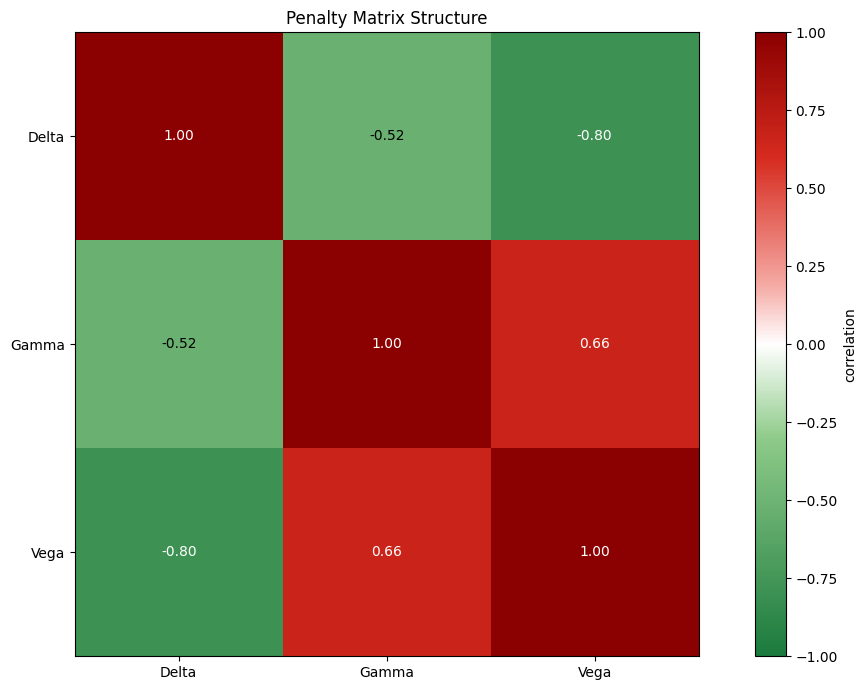

Saved penalty_matrix_heatmap.png


In [ ]:
# ============================================================
# PS8.3 — Penalty matrix heatmap (run after ps8_3_penalty_matrix.py)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

M = pd.read_csv('penalty_matrix.csv').values
labels = ['Delta', 'Gamma', 'Vega']

# Show CORRELATION (normalized), not raw covariance -- raw values span
# ~1e2 to ~1e16 across entries, which would make a heatmap unreadable.
D = np.sqrt(np.diag(M))
corr = M / np.outer(D, D)

from matplotlib.colors import LinearSegmentedColormap

# Pure red-green diverging colormap, biased toward red: green covers only
# the -1 to -0.3 range, white sits near 0, and red dominates from there
# through +1 (richer, more saturated red than a standard RdYlGn).
custom_cmap = LinearSegmentedColormap.from_list(
    'redgreen_red_heavy',
    [(0.00, '#1B7A3D'),   # strong green at -1
     (0.35, '#8FCB8A'),   # light green
     (0.50, '#FFFFFF'),   # white at 0
     (0.60, '#F4A6A0'),   # light red starts earlier -> red covers more range
     (0.80, '#D62B1F'),   # strong red
     (1.00, '#8B0000')],  # dark red at +1
)

fig, ax = plt.subplots(figsize=(11.5, 7))
im = ax.imshow(corr, cmap=custom_cmap, vmin=-1, vmax=1)

ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_title('Penalty Matrix Structure')

for i in range(3):
    for j in range(3):
        color = 'white' if abs(corr[i, j]) > 0.6 else 'black'
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', color=color, fontsize=10)

plt.colorbar(im, ax=ax, label='correlation')
plt.tight_layout()
plt.savefig('penalty_matrix_heatmap.png', dpi=150)
plt.show()
print("Saved penalty_matrix_heatmap.png")

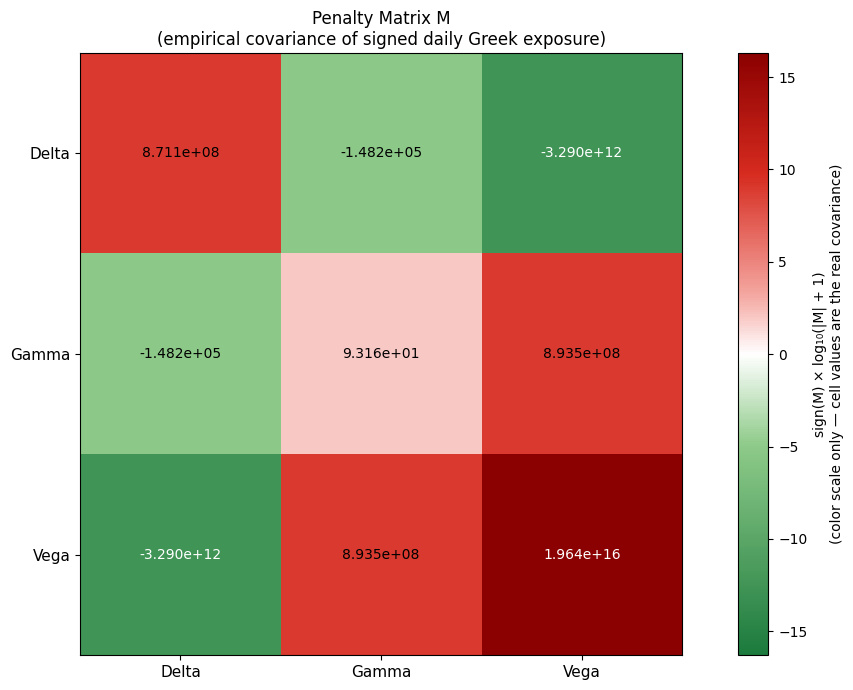

Saved penalty_matrix_covariance_heatmap.png


In [ ]:
# ============================================================
# PS8.3 — Visualize the ACTUAL penalty matrix M (raw covariance)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

M = pd.read_csv('penalty_matrix.csv').values
labels = ['Delta', 'Gamma', 'Vega']

# Covariance entries span ~1e2 to ~1e16 in magnitude, with mixed signs.
# A plain heatmap of raw values would show one dark cell and nothing else.
# Use a SIGNED-LOG transform for color only: sign(M) * log10(|M| + 1).
# The actual raw covariance values are still shown as the cell labels --
# this is a visualization aid, not a transformation of M itself.
signed_log = np.sign(M) * np.log10(np.abs(M) + 1)

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Pure red-green diverging colormap, biased toward red: green covers only
# the -1 to -0.3 range, white sits near 0, and red dominates from there
# through +1 (richer, more saturated red than a standard RdYlGn).
custom_cmap = LinearSegmentedColormap.from_list(
    'redgreen_red_heavy',
    [(0.00, '#1B7A3D'),   # strong green at -1
     (0.35, '#8FCB8A'),   # light green
     (0.50, '#FFFFFF'),   # white at 0
     (0.60, '#F4A6A0'),   # light red starts earlier -> red covers more range
     (0.80, '#D62B1F'),   # strong red
     (1.00, '#8B0000')],  # dark red at +1
)

fig, ax = plt.subplots(figsize=(11.5, 7))
vmax = np.abs(signed_log).max()
im = ax.imshow(signed_log, cmap=custom_cmap, vmin=-vmax, vmax=vmax)

ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(labels, fontsize=11)
ax.set_title('Penalty Matrix M\n(empirical covariance of signed daily Greek exposure)', fontsize=12)

for i in range(3):
    for j in range(3):
        val = M[i, j]
        # format each cell in scientific notation, matching its real magnitude
        label = f'{val:.3e}'
        color = 'white' if abs(signed_log[i, j]) > vmax * 0.55 else 'black'
        ax.text(j, i, label, ha='center', va='center', color=color, fontsize=10)

cbar = plt.colorbar(im, ax=ax, label='sign(M) \u00d7 log\u2081\u2080(|M| + 1)\n(color scale only \u2014 cell values are the real covariance)')
plt.tight_layout()
plt.savefig('penalty_matrix_covariance_heatmap.png', dpi=150)
plt.show()
print("Saved penalty_matrix_covariance_heatmap.png")

In [1]:
import numpy as np

# Your empirical covariance matrix M (Delta, Gamma, Vega order)
M = np.array([
    [8.711e8,  -1.482e5,  -3.290e12],
    [-1.482e5,  9.316e1,   8.935e8],
    [-3.290e12, 8.935e8,   1.964e16]
])

labels = ["Delta", "Gamma", "Vega"]

# --- Step 1: Extract std devs and correlation (sanity check) ---
std = np.sqrt(np.diag(M))
D_inv = np.diag(1 / std)
R = D_inv @ M @ D_inv
print("Recovered correlation matrix:\n", np.round(R, 3))

# --- Step 2: Z-score normalization ---
# Rescale so each Greek contributes on a comparable footing.
# This is equivalent to setting D = I, i.e., M_norm = R itself,
# UNLESS you want to apply explicit relative risk weights w_i.
w = np.array([1.0, 1.0, 1.0])   # <-- set these based on business priority
W = np.diag(w)
M_norm = W @ R @ W

print("\nNormalized penalty matrix (unit variance, weighted):\n", np.round(M_norm, 4))

# --- Step 3: Condition number check ---
cond = np.linalg.cond(M_norm)
print(f"\nCondition number: {cond:.2f}")

# --- Step 4: Shrinkage regularization (Ledoit-Wolf style, simplified) ---
# Blend toward identity to guarantee stable inversion if needed downstream.
def shrink(M, alpha=0.1):
    target = np.eye(M.shape[0]) * np.trace(M) / M.shape[0]
    return (1 - alpha) * M + alpha * target

M_shrunk = shrink(M_norm, alpha=0.1)
print(f"\nShrunk matrix condition number: {np.linalg.cond(M_shrunk):.2f}")

# --- Step 5: PSD verification ---
eigvals = np.linalg.eigvalsh(M_shrunk)
print("\nEigenvalues (all should be > 0):", np.round(eigvals, 4))
assert np.all(eigvals > 0), "Matrix is not positive definite!"

print("\nFinal penalty matrix M_final:\n", np.round(M_shrunk, 4))

Recovered correlation matrix:
 [[ 1.    -0.52  -0.795]
 [-0.52   1.     0.661]
 [-0.795  0.661  1.   ]]

Normalized penalty matrix (unit variance, weighted):
 [[ 1.     -0.5202 -0.7954]
 [-0.5202  1.      0.6606]
 [-0.7954  0.6606  1.    ]]

Condition number: 12.96

Shrunk matrix condition number: 8.38

Eigenvalues (all should be > 0): [0.2614 0.5472 2.1915]

Final penalty matrix M_final:
 [[ 1.     -0.4682 -0.7159]
 [-0.4682  1.      0.5945]
 [-0.7159  0.5945  1.    ]]
